# Giai đoạn 2: Phân tích Khám phá Dữ liệu và Trực quan hóa

Giai đoạn này tiến hành phân tích khám phá dữ liệu nhằm xác định các khu vực có tỷ lệ tội phạm bạo lực cao nhất tại Hoa Kỳ thông qua bản đồ nhiệt địa lý theo bang.

Song song đó, phân tích hệ số tương quan Pearson được thực hiện để kiểm chứng 5 giả thuyết kinh tế – xã hội liên quan đến tỷ lệ tội phạm bạo lực, bao gồm: cơ cấu tuổi dân số, trình độ học vấn, tình trạng nghèo đói, cấu trúc gia đình, và tỷ lệ thất nghiệp với các câu hỏi như sau:

1. **Tuổi tác:** Dân số trẻ có làm tăng tội phạm?
2. **Giáo dục:** Học vấn cao có giúp kìm hãm bạo lực?
3. **Kinh tế:** Nghèo đói có dẫn đến tội phạm?
4. **Nhập cư:** Cộng đồng nhập cư có thực sự tỷ lệ thuận với tội phạm?
5. **Dân tộc:** Yếu tố sắc tộc có mối liên hệ nào với an ninh cộng đồng?


In [35]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
load_dotenv()

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [36]:
#Load dataset đã làm sạch
load_dotenv(dotenv_path="../.env")

data_path = os.getenv("PROCESSED_DATA_PATH")

if data_path:
    print(f"Đang đọc dữ liệu từ đường dẫn cấu hình: {data_path}")
    df = pd.read_csv(data_path)

    print(f"Tải dữ liệu thành công! Tổng số dòng: {len(df)}")
    display(df.head())
else:
    print("Lỗi: Không tìm thấy file!")

Đang đọc dữ liệu từ đường dẫn cấu hình: ../data/processed/cleaned_crime_data.csv
Tải dữ liệu thành công! Tổng số dòng: 1994


,communityname,State,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,...,225.0,1301.78,716.0,4142.56,47.0,271.93,5.0,21.04,306.64,4479.66
4,Springfieldcity,MO,1,140494,2.45,2.51,95.65,0.90,0.95,18.09,...,2094.0,1386.46,7690.0,5091.64,454.0,300.60,134.0,88.72,442.95,6867.42


In [37]:
import os
from dotenv import load_dotenv

target_var = "violentPerPop"


crime_cols = ['murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
              'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
              'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop', 'nonViolPerPop']

df = df.drop(columns=[c for c in crime_cols if c in df.columns])


load_dotenv()
output_path = os.getenv("PROCESSED_DATA_PATH_TEMP")

os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)
print(f'Đã lưu thành công: "{output_path}"')

Đã lưu thành công: "../data/temp/temp_crime_data.csv"


## 1. Bản đồ nhiệt địa lý

### a. Tỷ lệ tội phạm bạo lực tại các bang nước Mỹ:

In [38]:
# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_1 = df[["State", "pop", "violentPerPop"]].dropna()

# 2. Tính tổng số vụ tội phạm bạo lực cho từng khu vực
crime_EDA_1["total_violent_crimes"] = (
    crime_EDA_1["violentPerPop"] / 100000
) * crime_EDA_1["pop"]

# 3. Gom nhóm theo bang và tính tổng
state_groups = (
    crime_EDA_1.groupby("State")
    .agg(tot_pop=("pop", "sum"), tot_vio=("total_violent_crimes", "sum"))
    .reset_index()
)

# Tính toán tỷ lệ tội phạm của từng bang
state_groups["crime_rate"] = state_groups["tot_vio"] / state_groups["tot_pop"]

state_groups_sorted = state_groups.sort_values(by="crime_rate", ascending=False)

# In kết quả để validate
print(state_groups_sorted)

# 4. Tạo thông tin hiển thị
state_groups["hover_text"] = (
    state_groups["State"].astype(str)
    + "<br>pop: "
    + state_groups["tot_pop"].map("{:,}".format)
)

# 5. Vẽ bản đồ
fig = px.choropleth(
    state_groups,
    locations="State",
    locationmode="USA-states",
    color="crime_rate",
    hover_name="State",
    color_continuous_scale="Reds",
    labels={"crime_rate": "Tỷ lệ tội phạm bạo lực"},
    scope="usa",
    title="Tỷ lệ tội phạm bạo lực tại các bang nước Mỹ",
)

fig.update_traces(marker_line_color="white", marker_line_width=2)

# Thêm DC vì locationmode="USA-states" không nhận DC
dc_data = state_groups[state_groups["State"] == "DC"]
if not dc_data.empty:
    dc_rate = dc_data["crime_rate"].values[0]
    dc_pop = dc_data["tot_pop"].values[0]

    fig.add_scattergeo(
        lon=[-77.0369],
        lat=[38.9072],
        mode="markers",
        marker=dict(
            size=12,
            color=[dc_rate],
            colorscale="Reds",
            cmin=state_groups["crime_rate"].min(),
            cmax=state_groups["crime_rate"].max(),
            line=dict(color="white", width=2),
        ),
        hovertemplate=(
            f"<b>DC</b><br>"
            f"Tỷ lệ tội phạm bạo lực: {dc_rate:.4f}<br>"
            f"pop: {dc_pop:,}<extra></extra>"
        ),
        name="DC",
        showlegend=False,
    )

fig.show()

   State   tot_pop        tot_vio  crime_rate
7     DC    606900   18500.618220    0.030484
18    MD    981159   25298.780649    0.025785
29    NY   9474916  172887.554684    0.018247
16    LA   1537451   27312.461019    0.017765
10    GA   1601370   26269.735330    0.016405
9     FL   4594142   73943.688810    0.016095
35    SC    791754   12251.003968    0.015473
20    MN    467411    6957.309236    0.014885
27    NM    582205    7791.111774    0.013382
1     AL   1686941   22472.282799    0.013321
2     AR    816863   10342.274771    0.012661
37    TN   1685221   20744.003938    0.012309
4     CA  21957110  265186.283219    0.012077
23    NC   2049543   23900.314186    0.011661
13    IN   2371482   23798.310729    0.010035
21    MO   1546912   15229.417636    0.009845
30    OH   4565967   40744.856719    0.008924
8     DE     27630     245.158227    0.008873
31    OK   1727382   15196.535346    0.008797
14    KS    304011    2659.153816    0.008747
42    WA   1943157   16947.578752 

Kết luận: Số liệu cho thấy Đặc khu Columbia (D.C.) dẫn đầu về tỷ lệ tội phạm bạo lực tại Hoa Kỳ. Theo sau D.C., Maryland là bang có tỷ lệ tội phạm bạo lực cao thứ hai, tiếp đến là New York, Louisiana, Georgia, Florida, South Carolina và Minnesota. Đáng chú ý, Maryland và D.C. có tỷ lệ tội phạm vượt trội hơn hẳn so với các bang còn lại trong nhóm, vốn có tỷ lệ gần như tương đương nhau. Mặt khác, New York và Florida lại có quy mô dân số lớn hơn rất nhiều so với các bang khác trong danh sách.

###  b. Tỷ lệ phần trăm người Mỹ gốc Phi

In [39]:
# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_3 = df[["State", "pop", "pctBlack"]].dropna()

# 2. Tính số lượng người Mỹ gốc Phi cho từng khu vực
crime_EDA_3["black_pop_absolute"] = crime_EDA_3["pctBlack"] * crime_EDA_3["pop"]

# 3. Gom nhóm theo bang và tính tổng
state_groups = (
    crime_EDA_3.groupby("State")
    .agg(
        tot_pop=("pop", "sum"), tot_black_pop=("black_pop_absolute", "sum")
    )
    .reset_index()
)

# Tính tỷ lệ phần trăm người Mỹ gốc Phi của từng bang
state_groups["black_pop_rate"] = (
    state_groups["tot_black_pop"] / state_groups["tot_pop"]
) * 100

# Tính toán tỷ lệ tội phạm của từng bang
state_groups_sorted = state_groups.sort_values(by="black_pop_rate", ascending=False)

# In kết quả để validate
print(state_groups_sorted)

# 4. Tạo thông tin hiển thị
state_groups["hover_text"] = (
    state_groups["State"].astype(str)
    + "<br>pop: "
    + state_groups["tot_pop"].map("{:,}".format)
)

# 5. Vẽ bản đồ
fig = px.choropleth(
    state_groups,
    locations="State",
    locationmode="USA-states",
    color="black_pop_rate",
    hover_name="State",
    hover_data={
        "State": False,
        "black_pop_rate": ":.2f",
    },
    color_continuous_scale="Blues",
    labels={"black_pop_rate": "Tỷ lệ người Mỹ gốc Phi (%)"},
    scope="usa",
    title="Tỷ lệ phần trăm người Mỹ gốc Phi",
)


fig.update_traces(marker_line_color="white", marker_line_width=2)

# Hiển thị bản đồ
fig.show()

   State   tot_pop  tot_black_pop  black_pop_rate
7     DC    606900   3.995830e+07     6584.000000
18    MD    981159   4.810841e+07     4903.222964
10    GA   1601370   7.346388e+07     4587.564204
16    LA   1537451   6.890857e+07     4482.001045
22    MS    623259   2.770380e+07     4444.990676
1     AL   1686941   6.017506e+07     3567.110933
35    SC    791754   2.596840e+07     3279.856957
23    NC   2049543   6.369898e+07     3107.960277
8     DE     27630   8.543196e+05     3092.000000
37    TN   1685221   5.082178e+07     3015.733794
40    VA   2216217   6.451633e+07     2911.101719
29    NY   9474916   2.491206e+08     2629.264618
2     AR    816863   1.843094e+07     2256.307585
33    PA   4247131   8.890085e+07     2093.197628
30    OH   4565967   8.841449e+07     1936.380464
9     FL   4594142   8.316377e+07     1810.213330
13    IN   2371482   3.927037e+07     1655.941970
15    KY    802721   1.321827e+07     1646.682649
26    NJ   5891576   9.386645e+07     1593.231510


Kết luận: Về mặt nhân khẩu học, cộng đồng người Mỹ gốc Phi chiếm hơn 65% dân số của D.C. Các bang khác có tỷ lệ người Mỹ gốc Phi cao bao gồm Maryland, Georgia, Louisiana và Mississippi. Đây cũng chính là những bang nằm trong nhóm có tỷ lệ tội phạm bạo lực và phi bạo lực cao nhất. Sự trùng hợp này lý giải vì sao các vấn đề tội phạm thường dễ dẫn đến những định kiến về sắc tộc. Đây là một mối tương quan phức tạp cần được nghiên cứu và phân tích sâu hơn trong các phần tiếp theo.

### 2. Tương quan của các yếu tố kinh tế - xã hội đến tỷ lệ tội phạm

Chúng tôi khép lại phần phân tích khám phá dữ liệu trực quan bằng việc xem xét các yếu tố kinh tế - xã hội có tương quan như thế nào đến tỷ lệ tội phạm bạo lực.

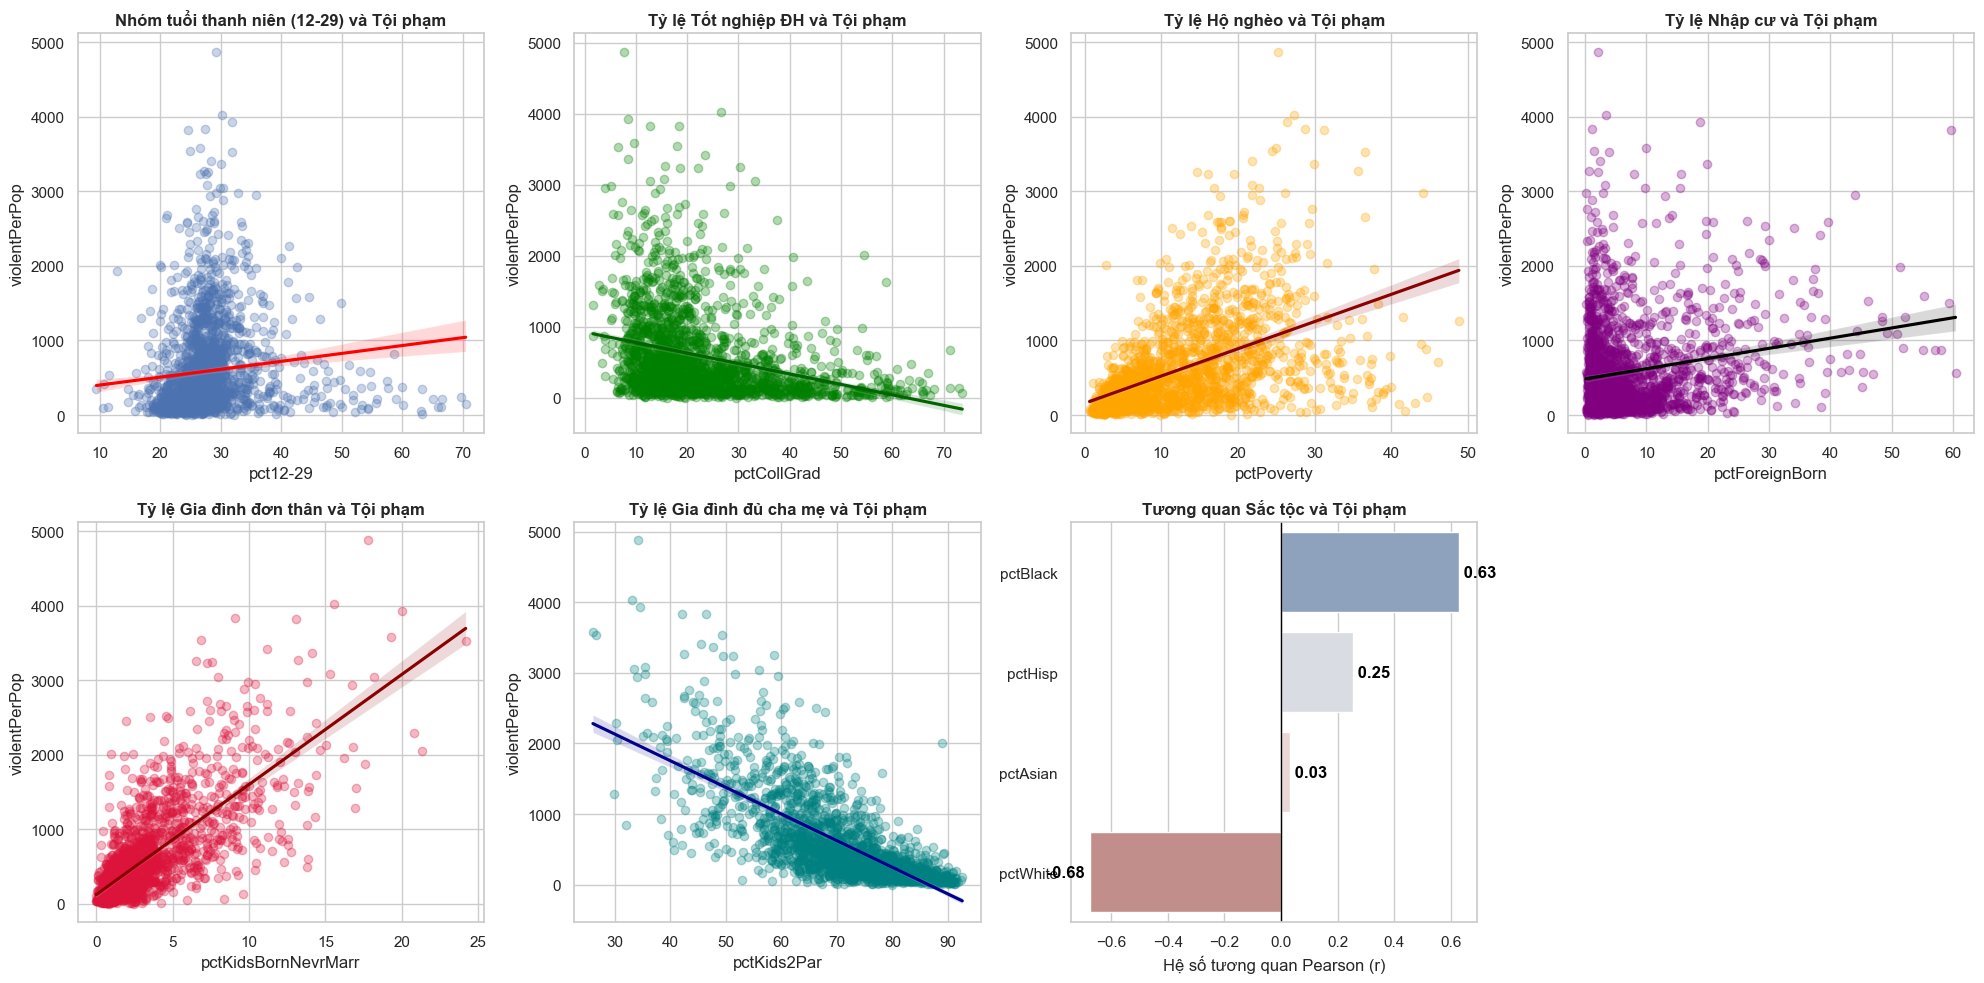

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


TARGET_COL = "violentPerPop"

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes = axes.flatten()

# 1. Tuổi tác
sns.regplot(data=df, x='pct12-29', y=TARGET_COL, ax=axes[0], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
axes[0].set_title('Nhóm tuổi thanh niên (12-29) và Tội phạm', fontweight='bold')

# 2. Giáo dục
sns.regplot(data=df, x='pctCollGrad', y=TARGET_COL, ax=axes[1], color='green', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkgreen'})
axes[1].set_title('Tỷ lệ Tốt nghiệp ĐH và Tội phạm', fontweight='bold')

# 3. Kinh tế
sns.regplot(data=df, x='pctPoverty', y=TARGET_COL, ax=axes[2], color='orange', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkred'})
axes[2].set_title('Tỷ lệ Hộ nghèo và Tội phạm', fontweight='bold')

# 4: Nhập cư
sns.regplot(data=df, x='pctForeignBorn', y=TARGET_COL, ax=axes[3], color='purple', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'black'})
axes[3].set_title('Tỷ lệ Nhập cư và Tội phạm', fontweight='bold')

# 5: Cấu trúc gia đình đơn thân
sns.regplot(data=df, x='pctKidsBornNevrMarr', y=TARGET_COL, ax=axes[4], color='crimson', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkred'})
axes[4].set_title('Tỷ lệ Gia đình đơn thân và Tội phạm', fontweight='bold')

# 6: Cấu trúc gia đình có đủ cha mẹ
sns.regplot(data=df, x='pctKids2Par', y=TARGET_COL, ax=axes[5], color='teal', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkblue'})
axes[5].set_title('Tỷ lệ Gia đình đủ cha mẹ và Tội phạm', fontweight='bold')

# 7: Sắc tộc
race_vars = ['pctBlack', 'pctWhite', 'pctAsian', 'pctHisp']

# Tính toán tương quan với biến mục tiêu và sắp xếp
race_corr = df[race_vars + [TARGET_COL]].corr()[[TARGET_COL]].drop(TARGET_COL)
race_corr = race_corr.sort_values(by=TARGET_COL, ascending=False)

# Vẽ biểu đồ cột ngang
sns.barplot(x=race_corr[TARGET_COL], y=race_corr.index, ax=axes[6], palette='vlag')


axes[6].set_title('Tương quan Sắc tộc và Tội phạm', fontweight='bold')
axes[6].set_xlabel('Hệ số tương quan Pearson (r)')
axes[6].set_ylabel('')
axes[6].axvline(0, color='black', linewidth=1) # Thêm đường trục 0 ở giữa để phân biệt âm/dương


for i, val in enumerate(race_corr[TARGET_COL]):
    axes[6].text(val, i, f" {val:.2f} ", va='center',
                 ha='left' if val > 0 else 'right', color='black', fontweight='bold')

# 8: Tắt trục của ô cuối cùng vì chỉ có 7 biểu đồ
axes[7].axis('off')

plt.tight_layout()
plt.show()

Qua biểu đồ phân tích, có thể thấy yếu tố kinh tế, cụ thể là tỷ lệ hộ nghèo, có tác động mạnh mẽ và trực tiếp nhất đến tỷ lệ tội phạm bạo lực. Trái lại, tỷ lệ tốt nghiệp đại học cho thấy mối tương quan nghịch rõ rệt, nhấn mạnh vai trò của giáo dục và sự ổn định kinh tế trong việc giảm thiểu tội phạm. Các yếu tố về độ tuổi thanh niên chỉ có tương quan dương nhẹ, trong khi tỷ lệ người nhập cư hầu như không thể hiện mối liên hệ đáng kể nào với tội phạm. Đặc biệt, đối với các chỉ số về sắc tộc, dù xuất hiện các hệ số tương quan đáng chú ý, nhưng cần hết sức thận trọng khi diễn giải; các kết quả này thường là hệ quả của những bất bình đẳng mang tính hệ thống như phân bổ nguồn lực và cơ hội hơn là bản chất sắc tộc. Nhìn chung, kết quả này cho thấy tội phạm là một vấn đề xã hội đa chiều, đòi hỏi phải sử dụng các mô hình hồi quy đa biến để tách biệt ảnh hưởng thực sự của từng biến số thay vì chỉ dựa vào tương quan đơn lẻ.

### 3. Top 15 biến có ảnh hưởng mạnh nhất đến tỷ lệ tội phạm bạo lực


=== TOP 15 BIẾN KINH TẾ-XÃ HỘI CÓ TƯƠNG QUAN MẠNH NHẤT ===
(Đã loại trừ các biến thành phần của tội phạm)
pctKidsBornNevrMarr    0.738089
pctKids2Par           -0.728059
pct2Par               -0.698641
pctWhite              -0.676849
pctKids-4w2Par        -0.658436
pct12-17w2Par         -0.655628
pctBlack               0.628368
pctPubAsst             0.563107
pctWdiv               -0.557787
pctFemDivorc           0.537303
pctAllDivorc           0.536549
pctMaleDivorc          0.510456
pctPersOwnOccup       -0.507330
pctPoverty             0.505349
pctUnemploy            0.483441
Name: violentPerPop, dtype: float64
--------------------------------------------------


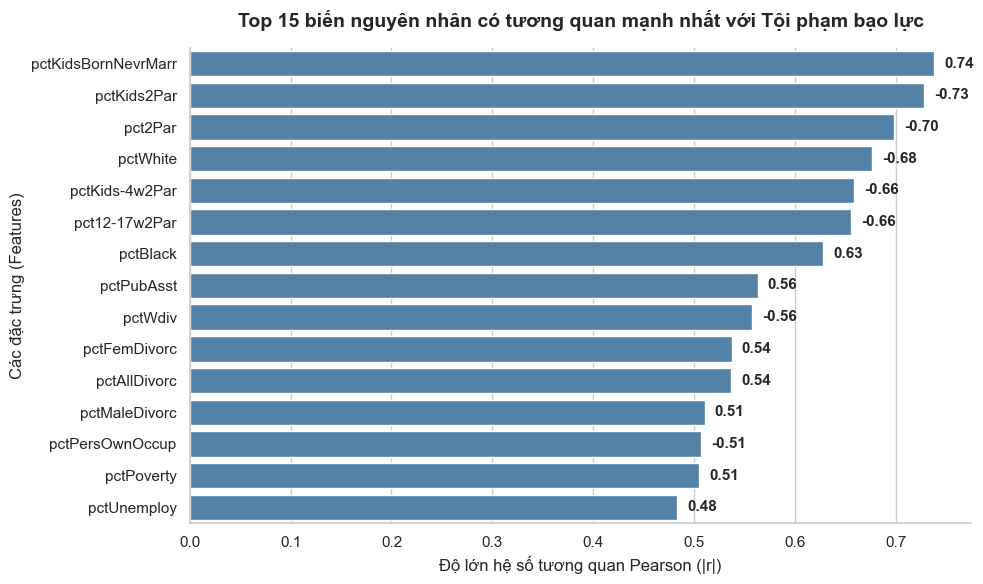


=== KIỂU DỮ LIỆU CỦA TOP 15 BIẾN NÀY ===
pctKidsBornNevrMarr    float64
pctKids2Par            float64
pct2Par                float64
pctWhite               float64
pctKids-4w2Par         float64
pct12-17w2Par          float64
pctBlack               float64
pctPubAsst             float64
pctWdiv                float64
pctFemDivorc           float64
pctAllDivorc           float64
pctMaleDivorc          float64
pctPersOwnOccup        float64
pctPoverty             float64
pctUnemploy            float64
dtype: object
--------------------------------------------------


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 2. Tính toán tương quan của các biến còn lại với biến mục tiêu
numeric_df = df.select_dtypes(include=[np.number])
all_correlations = numeric_df.corr()[[target_var]].drop(target_var)

# Thêm cột giá trị tuyệt đối để sắp xếp độ mạnh của tương quan
all_correlations['abs_corr'] = all_correlations[target_var].abs()
correlations_sorted = all_correlations.sort_values(by='abs_corr', ascending=False)

# Lấy Top 15 biến có ảnh hưởng mạnh nhất
top_15_vars = correlations_sorted.head(15)

print("=== TOP 15 BIẾN KINH TẾ-XÃ HỘI CÓ TƯƠNG QUAN MẠNH NHẤT ===")
print("(Đã loại trừ các biến thành phần của tội phạm)")
print(top_15_vars[target_var])
print("-" * 50)

# 3. Trực quan hóa so sánh

ax = sns.barplot(x=top_15_vars['abs_corr'], y=top_15_vars.index, color='steelblue')


plt.title('Top 15 biến nguyên nhân có tương quan mạnh nhất với Tội phạm bạo lực',
          fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Độ lớn hệ số tương quan Pearson (|r|)', fontsize=12)
plt.ylabel('Các đặc trưng (Features)', fontsize=12)


for i, (index, row) in enumerate(top_15_vars.iterrows()):
    actual_corr = row[target_var]
    ax.text(row['abs_corr'] + 0.01, i, f"{actual_corr:.2f}", va='center', fontsize=11, fontweight='bold')


sns.despine()
plt.tight_layout()
plt.show()

print("\n=== KIỂU DỮ LIỆU CỦA TOP 15 BIẾN NÀY ===")
print(df[top_15_vars.index].dtypes)
print("-" * 50)

Mô hình chỉ ra 3 nhóm yếu tố chính có ảnh hưởng mạnh nhất đến tỷ lệ tội phạm bạo lực:

Cấu trúc gia đình (Quan trọng nhất): Sự rạn nứt gia đình (tỷ lệ ly hôn cao, cha mẹ đơn thân, chưa kết hôn) có tương quan thuận rất mạnh với sự gia tăng tội phạm. Ngược lại, cấu trúc gia đình trọn vẹn (có cả cha và mẹ) là yếu tố bảo vệ vững chắc nhất giúp giảm thiểu tỷ lệ này.

Điều kiện kinh tế - xã hội: Các khu vực có tỷ lệ nghèo đói, thất nghiệp và nhận trợ cấp xã hội cao thường đi kèm với tỷ lệ tội phạm cao. Các khu vực có mức độ tự chủ tài chính tốt (tỷ lệ sở hữu nhà, thu nhập từ đầu tư cao) ghi nhận tỷ lệ tội phạm thấp hơn.
Nhân khẩu học: Đặc điểm chủng tộc có sự phân hóa rõ rệt, tuy nhiên điều này phản ánh hệ quả của sự phân tầng kinh tế - xã hội và rào cản lịch sử tại các khu vực khảo sát hơn là nguyên nhân trực tiếp.

Kết luận: Tội phạm bạo lực có nguồn gốc sâu xa từ sự bất ổn định của nền tảng gia đình và những khó khăn về kinh tế - xã hội.